In [1]:
import virtualizarr as vz

from obstore.store import from_url
from obspec_utils.registry import ObjectStoreRegistry
from gribberish.virtualizarr import GribberishParser

#### Generate URLS for the grib files we want to ingest

In [4]:
bucket = "s3://noaa-gefs-pds"
date = "20260607"
cycle = "00"

store = from_url(bucket, region="us-east-1", skip_signature=True)
registry = ObjectStoreRegistry({bucket: store})

base = f"{bucket}/gefs.{date}/{cycle}/wave/gridded"

# There are 31 members, but for this demonstration we will load 3 of them
members = ["c00"] + [f"p{i:02d}" for i in range(1, 30)]

# We are only going to grab a few hours
#hours = list(range(0, 241, 3)) + list(range(246, 385, 6))
hours = [0, 3, 6]

urls = [
    [
        f"{base}/gefs.wave.t{cycle}z.{member}.global.0p25.f{fh:03d}.grib2"
        for fh in hours
    ]
    for member in members
]

f"Generated {len(hours) * len(members)} urls for Virtual GEFS Wave Dataset"

'Generated 90 urls for Virtual GEFS Wave Dataset'

#### Use the Virtualizarr Parser to create a vritual dataset

In [5]:
parser = GribberishParser(use_index=True)

vds = vz.open_virtual_mfdataset(
    urls,
    parser=parser,
    registry=registry,
    combine="nested",
    concat_dim=["number", "time"],
    coords="minimal",
    compat="override",
    data_vars="all",
    combine_attrs="drop_conflicts",
)

vds

<xarray.Dataset> Size: 17GB
Dimensions:      (number: 30, time: 3, latitude: 721, longitude: 1440, seq: 3)
Coordinates:
  * time         (time) datetime64[ns] 24B 2026-06-07 ... 2026-06-07T06:00:00
  * latitude     (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude    (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
  * seq          (seq) float64 24B 1.0 2.0 3.0
    spatial_ref  int64 8B ManifestArray<shape=(), dtype=int64, chunks=()>
Dimensions without coordinates: number
Data variables: (12/17)
    ugrd         (number, time, latitude, longitude) float64 748MB ManifestAr...
    dirpw        (number, time, latitude, longitude) float64 748MB ManifestAr...
    wvdir        (number, time, latitude, longitude) float64 748MB ManifestAr...
    perpw        (number, time, latitude, longitude) float64 748MB ManifestAr...
    vgrd         (number, time, latitude, longitude) float64 748MB ManifestAr...
    swell        (number, time, seq, latitude, longitude) float64 2GB Manifes...
    ...           ...
    wwsdir       (number, time, latitude, longitude) float64 748MB ManifestAr...
    wvper        (number, time, latitude, longitude) float64 748MB ManifestAr...
    htsgw        (number, time, latitude, longitude) float64 748MB ManifestAr...
    wdir         (number, time, latitude, longitude) float64 748MB ManifestAr...
    imwf         (number, time, latitude, longitude) float64 748MB ManifestAr...
    wvhgt        (number, time, latitude, longitude) float64 748MB ManifestAr...
Attributes:
    meta:     Generated with gribberishpy

#### Save the virtual dataset to icechunk 

In [6]:
import icechunk

config = icechunk.RepositoryConfig.default()

config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix="s3://noaa-gefs-pds/",
        store=icechunk.s3_store(
            region="us-east-1",
            anonymous=True,
        ),
    )
)

storage = icechunk.local_filesystem_storage("gefs-wave.icechunk")
repo = icechunk.Repository.create(storage, config)
repo

  2026-06-12T19:58:08.312216Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196



<icechunk.Repository (v2)>
storage:
    <icechunk.Storage>
    type: local filesystem
    path: gefs-wave.icechunk
config: <RepositoryConfig ...>

In [7]:
session = repo.writable_session("main")

vds.vz.to_icechunk(session.store)

snapshot_id = session.commit("Virtualized GEFS wave")
repo.save_config()

snapshot_id

'TVAXJZZKV2W8GEXK4XD0'

#### Open the icechunk repository from disk, with our virtual grib references authorized

In [8]:
import xarray as xr

repo = icechunk.Repository.open(
    storage=icechunk.local_filesystem_storage("gefs-wave.icechunk"),
    authorize_virtual_chunk_access={
        "s3://noaa-gefs-pds/": None,
    }
)

session = repo.readonly_session("main")

ds = xr.open_zarr(session.store)
ds

  2026-06-12T19:58:11.414911Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196



<xarray.Dataset> Size: 17GB
Dimensions:      (number: 30, time: 3, latitude: 721, longitude: 1440, seq: 3)
Coordinates:
  * time         (time) datetime64[ns] 24B 2026-06-07 ... 2026-06-07T06:00:00
  * latitude     (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude    (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
  * seq          (seq) float64 24B 1.0 2.0 3.0
    spatial_ref  int64 8B ...
Dimensions without coordinates: number
Data variables: (12/17)
    dirpw        (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    imwf         (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    perpw        (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    htsgw        (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    icec         (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    mwsper       (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    ...           ...
    wvdir        (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    wvhgt        (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    swper        (number, time, seq, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 1, 721, 1440), meta=np.ndarray>
    wdir         (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    wvper        (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    wwsdir       (number, time, latitude, longitude) float64 748MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
Attributes:
    meta:     Generated with gribberishpy

#### Explore the data!

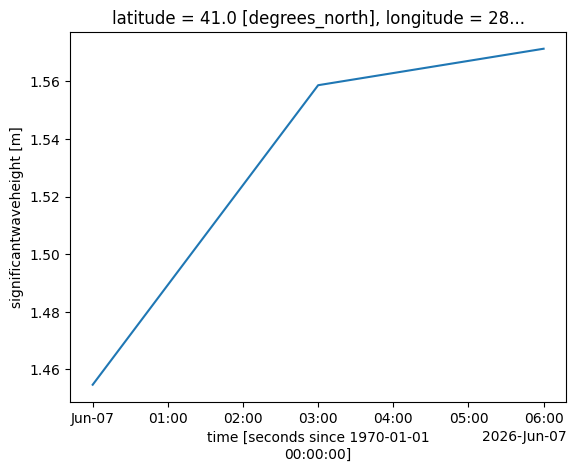

In [9]:
mean_wave_height = ds["htsgw"].mean(dim="number")
mean_wave_height.sel(latitude=40.967, longitude=360-71.124, method='nearest').plot()